In [8]:
from getpass import getpass
import os
os.environ["OPENAI_API_KEY"] = getpass("OpenAI Key: ")
os.environ["TAVILY_API_KEY"] = getpass("Tavily Key: ")

In [14]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.tools import tool

In [32]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatOpenAI(model="gpt-4o", temperature=0, max_completion_tokens=2000)

tavily_search = TavilySearchAPIWrapper()
@tool
def search_web(query: str, num_result=5):
    """
    Search web for a query. Useful for general information or general news
    """
    results = tavily_search.raw_results(query=query,
                                        max_results=num_result,
                                        search_depth="advanced",
                                        include_raw_content=True)
    return results

tools = [search_web]
llm_with_tools = llm.bind_tools(tools=tools)

In [16]:
response = llm_with_tools.invoke("Which team won in fifa today ?")
response.content

''

In [18]:
def tool_calling(state: State)->State:
    current_state = state["messages"]
    return {"messages": [llm_with_tools.invoke(current_state)]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              tools_condition,
                              ["tools", END])
builder.add_edge("tools", END)
graph = builder.compile()

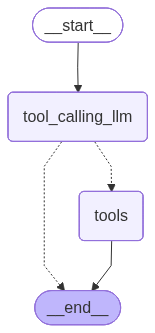

In [19]:
graph

In [22]:
query = "Who won the FIFA 2026 match today ?"
for event in graph.stream({"messages": query},
                           stream_mode="updates"):
    print(event)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 73, 'total_tokens': 97, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_97db7598f6', 'id': 'chatcmpl-Dr6JczLmhnFkqaciE4Q97JSKtzbTB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ecc89-9ee0-70a0-9c98-13212c5eaefe-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'FIFA 2026 match results October 2023'}, 'id': 'call_7zGfVRl5lj3JJcq0WikaGYJk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 24, 'total_tokens': 97, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'out

In [27]:
agent_builder = StateGraph(State)
agent_builder.add_node("tool_calling_llm", tool_calling)
agent_builder.add_node("tools", ToolNode(tools=tools))
agent_builder.add_edge(START, "tool_calling_llm")
agent_builder.add_conditional_edges("tool_calling_llm",
                              tools_condition,
                              ["tools", END])
agent_builder.add_edge("tools", "tool_calling_llm")
agent_graph = agent_builder.compile()

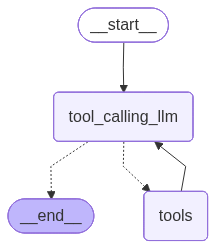

In [28]:
agent_graph

In [33]:
query = "Who won the FIFA 2026 match today ?"
for event in agent_graph.stream({"messages": query},
                           stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Who won the FIFA 2026 match today ?
================================== Ai Message ==================================
Tool Calls:
  search_web (call_7zvJGrq9tCLdd7kiwqTbHLHf)
 Call ID: call_7zvJGrq9tCLdd7kiwqTbHLHf
  Args:
    query: FIFA 2026 match results
    num_result: 1
================================= Tool Message =================================
Name: search_web

{"query": "FIFA 2026 match results", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.espn.com/soccer/story/_/id/48939282/2026-fifa-world-cup-fixtures-results-match-schedule-group-stage-knockout-rounds-bracket", "title": "2026 FIFA World Cup match schedule: Fixtures, results, features", "content": "4\n\nImage 28: Laugh Laugh\n\n3\n\nImage 29: Wow Wow\n\n2\n\nImage 30: Celebrate Celebrate\n\n1\n\nImage 31: Interesting Interesting\n\n1\n\nCheck out all the fixtures, features and results for the 202